[Reference](https://medium.com/data-science-collective/detecting-peaks-and-valleys-learn-the-essentials-for-accurate-analysis-295b2a002f62)

In [1]:
pip install findpeaks

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.0/75.0 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 190.4/190.4 kB 13.9 MB/s eta 0:00:00


# 1. Peak Detection With The Topology Method

Text(0, 0.5, 'Value')

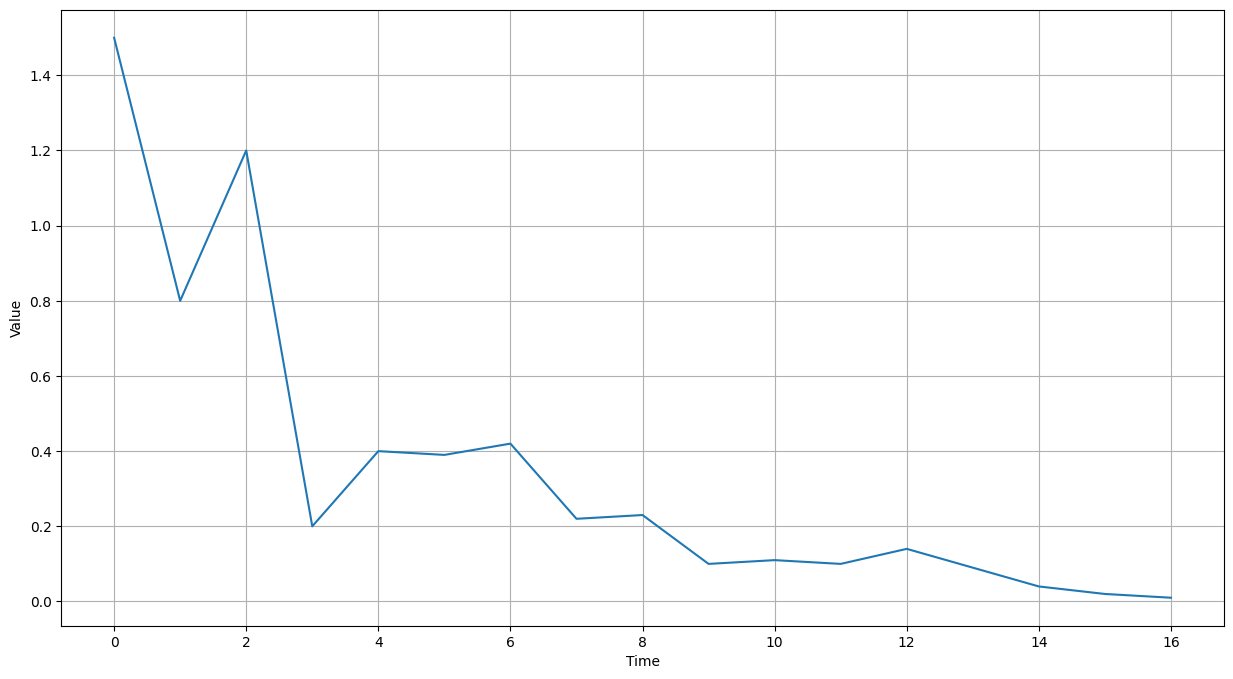

In [2]:
import matplotlib.pyplot as plt
# Import library
from findpeaks import findpeaks
# Initialize
fp = findpeaks(method='topology')
# Example 1d-vector
X = fp.import_example('1dpeaks')

# Plot
plt.figure(figsize=(15, 8), dpi=100)
plt.plot(X)
plt.grid(True)
plt.xlabel('Time')
plt.ylabel('Value')

INFO:findpeaks.stats:Detect peaks using topology method with limit at -0.99.
DEBUG:findpeaks.stats:Making values unique
INFO:findpeaks.stats:Topology
34it [00:00, 24223.94it/s]
INFO:findpeaks.findpeaks:Plotting persistence axis 2
100%|██████████| 7/7 [00:00<00:00, 1003.39it/s]
INFO:findpeaks.findpeaks:Plotting persistence axis 1
100%|██████████| 7/7 [00:00<00:00, 2581.79it/s]


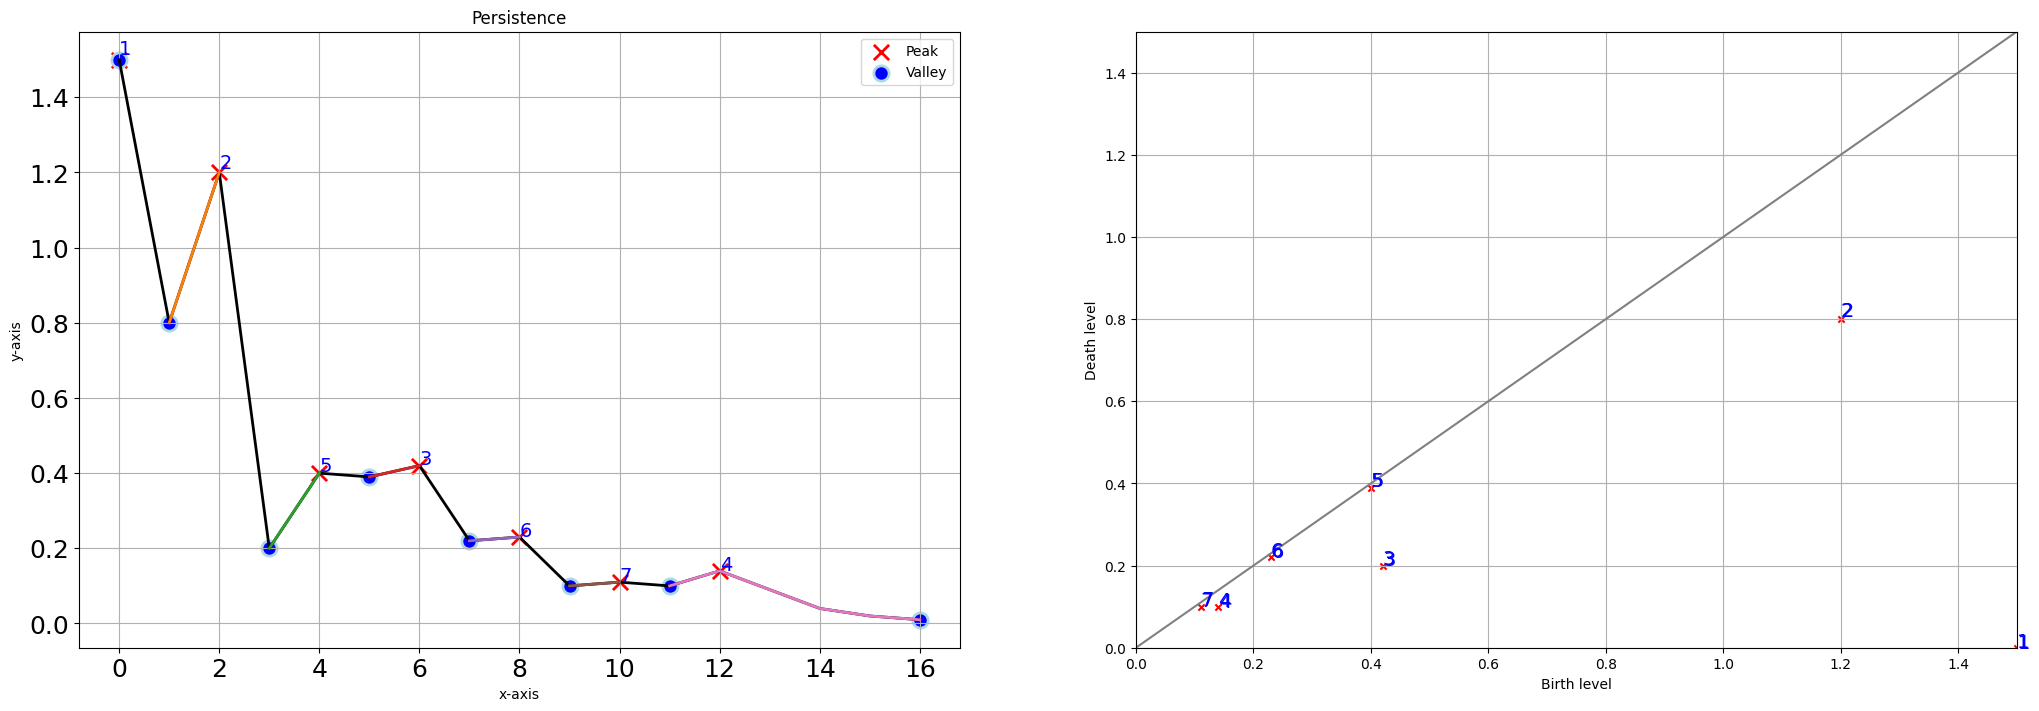

(<Axes: title={'center': 'Persistence'}, xlabel='x-axis', ylabel='y-axis'>,
 <Axes: xlabel='Birth level', ylabel='Death level'>)

In [3]:
# Fit topology method on the 1D vector
results = fp.fit(X)

# Plot the results
fp.plot_persistence(figsize=(25,8))

INFO:findpeaks.findpeaks:Downloading from github source: [https://erdogant.github.io/datasets/images/complex_peaks.png]
INFO:findpeaks.stats:Scaling image between [0-255] and to uint8
INFO:findpeaks.stats:Conversion to gray image.
INFO:findpeaks.stats:Denoising with [lee_sigma], window: [5].
INFO:findpeaks.stats:Detect peaks using topology method with limit at 5.
INFO:findpeaks.stats:Topology
20056it [00:00, 26856.24it/s]
INFO:findpeaks.findpeaks:Fin.
INFO:findpeaks.findpeaks:Plotting persistence axis 2
100%|██████████| 47/47 [00:00<00:00, 436.46it/s]
INFO:findpeaks.findpeaks:Plotting loci of birth..
INFO:findpeaks.findpeaks:Plotting loci of births
47it [00:00, 506.14it/s]


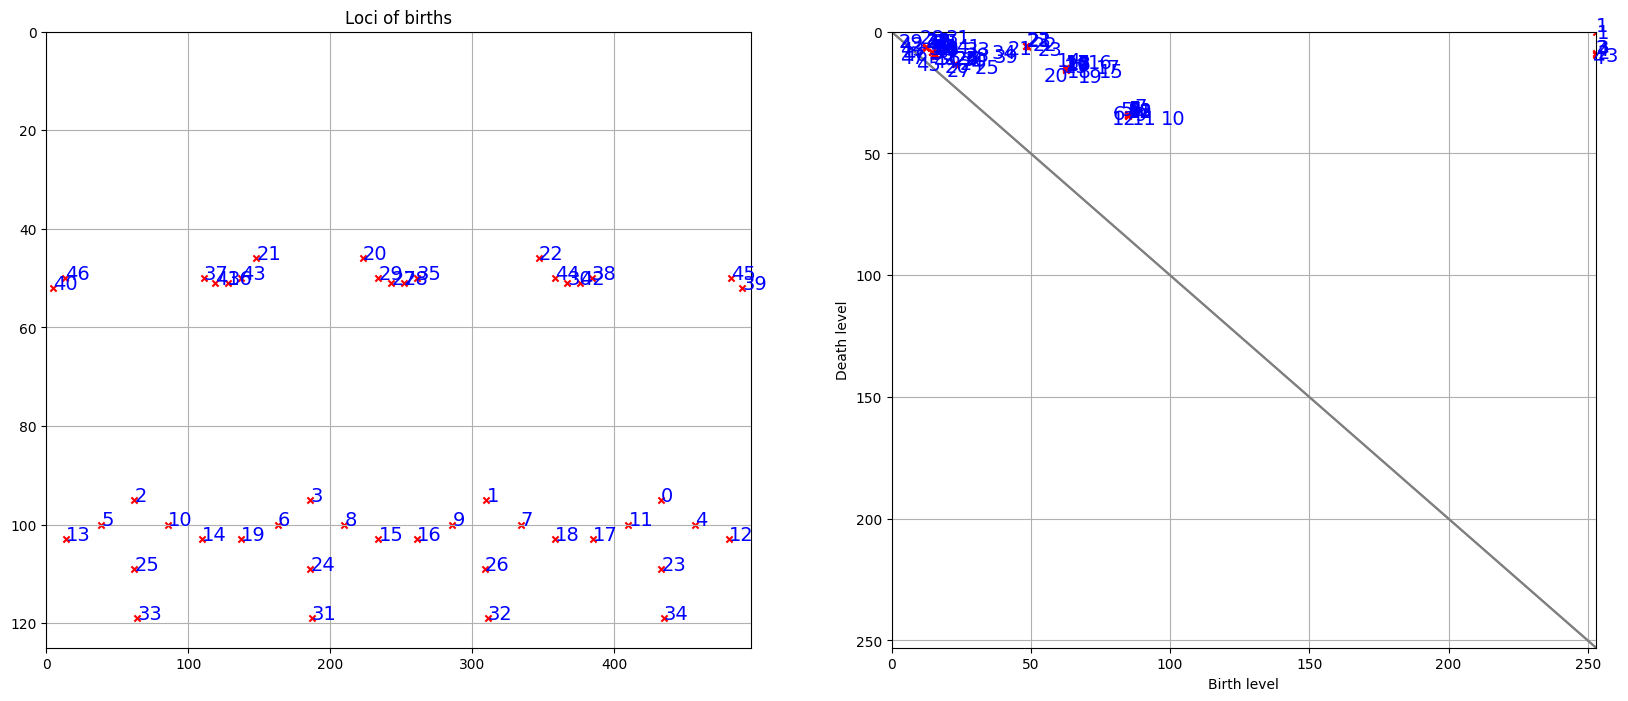

INFO:findpeaks.findpeaks:Annotating peaks
47it [00:00, 2625.84it/s]
INFO:findpeaks.findpeaks:Annotating valleys
0it [00:00, ?it/s]


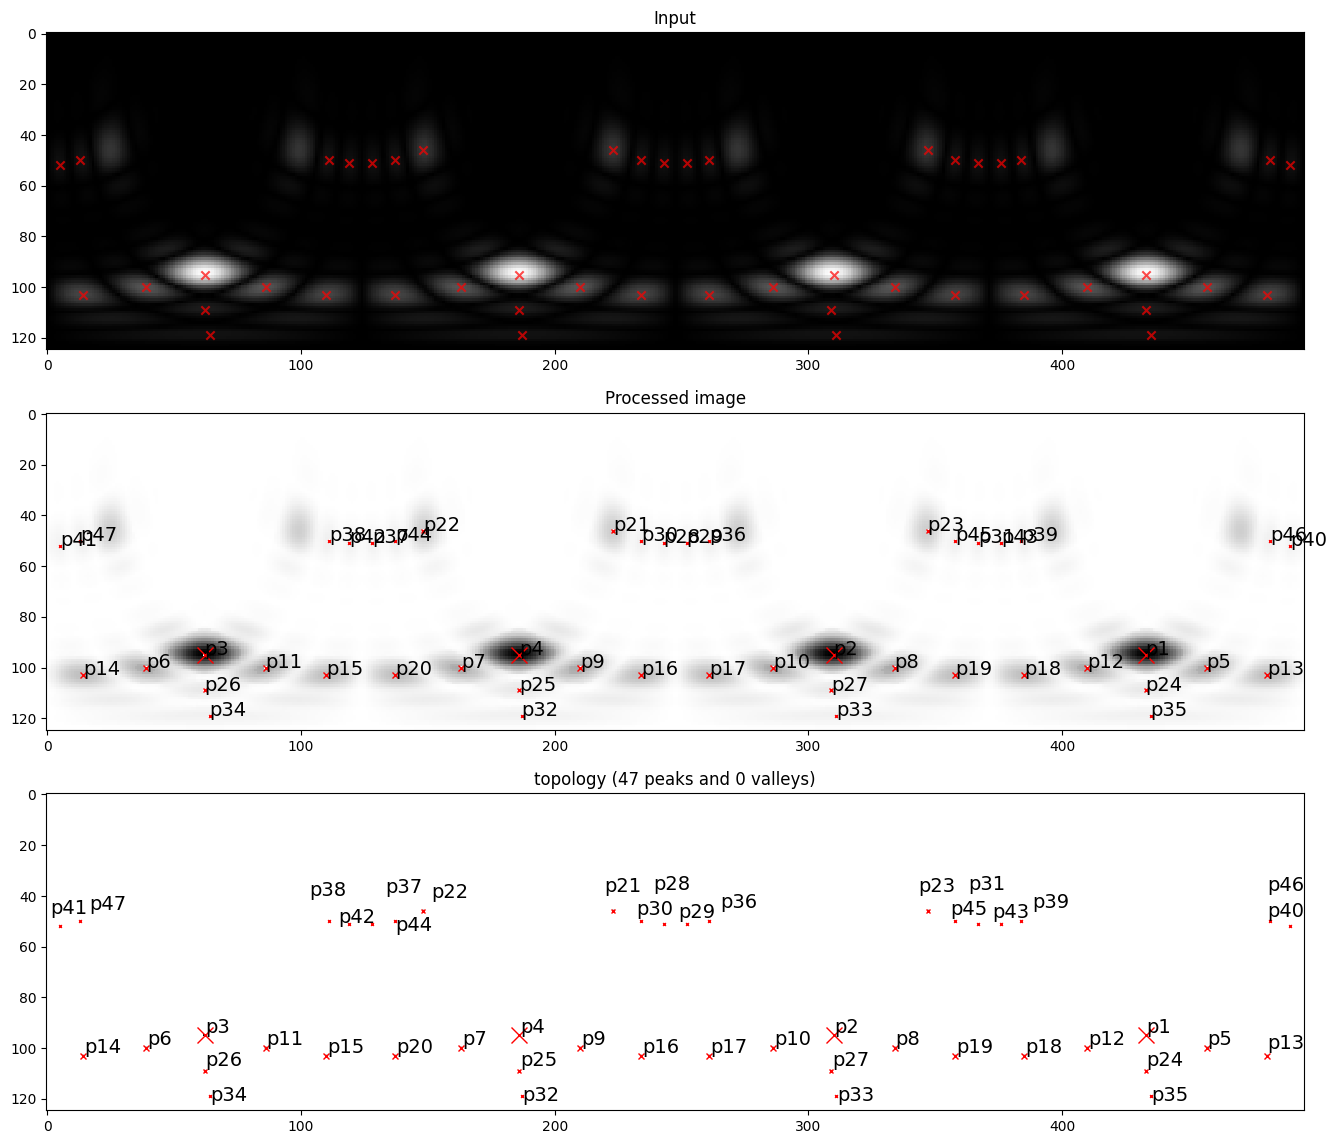

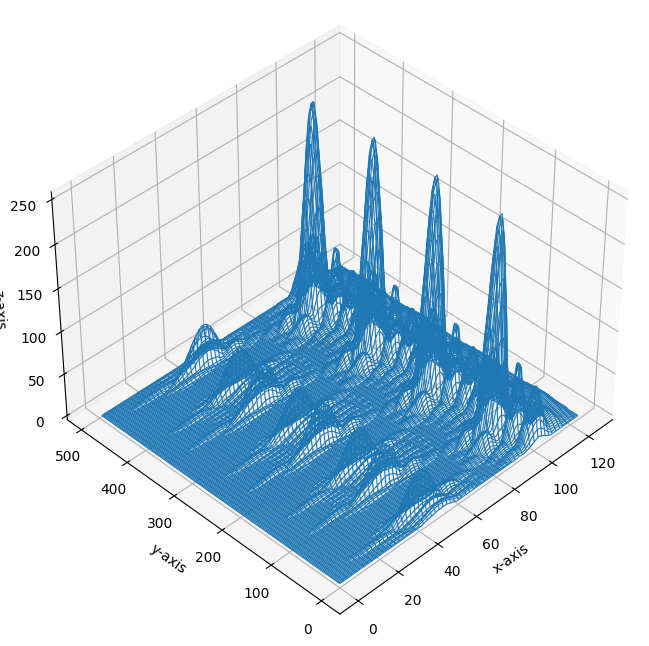

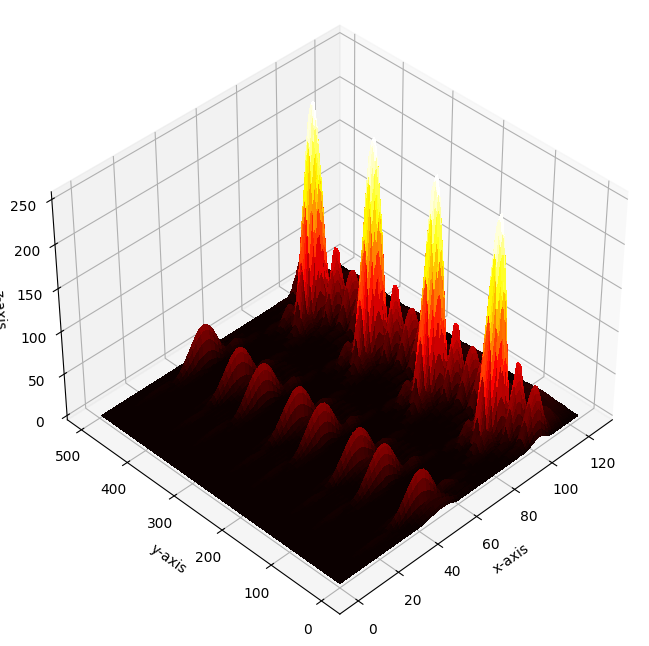

In [4]:
# Import findpeaks
from findpeaks import findpeaks

# Set findpeaks with its parameters
fp = findpeaks(method='topology', whitelist='peak', limit=5, denoise='lee_sigma', params={'window': 5})

# Read image from url
path = r'https://erdogant.github.io/datasets/images/complex_peaks.png'
X = fp.imread(path)

# Detect peaks
results = fp.fit(X)

# Show persistence plot
fp.plot_persistence()
# Show plot
fp.plot(figsize=(25, 14), text=True, marker='x', color='#ff0000', figure_order='vertical', fontsize=14)
# Mesh plot
fp.plot_mesh(view=(40, 225), cmap='hot')

# Results in dataframe
result_df = results['persistence']


# 2. Peak Detection With The Mask Method

INFO:findpeaks.findpeaks:Downloading from github source: [https://erdogant.github.io/datasets/2dpeaks.zip]
INFO:findpeaks.findpeaks:Import [/usr/local/lib/python3.12/dist-packages/findpeaks/data/2dpeaks.zip]
INFO:findpeaks.stats:Scaling image between [0-255] and to uint8
INFO:findpeaks.stats:Conversion to gray image.
INFO:findpeaks.stats:Image is already grayscale, no conversion needed.
INFO:findpeaks.stats:Denoising with [fastnl], window: [3].
INFO:findpeaks.stats:Detect peaks using the mask method with limit=0.
INFO:findpeaks.findpeaks:Fin.
INFO:findpeaks.stats:Scaling image between [0-255] and to uint8
INFO:findpeaks.stats:Conversion to gray image.
INFO:findpeaks.stats:Image is already grayscale, no conversion needed.
INFO:findpeaks.stats:Denoising with [fastnl], window: [3].


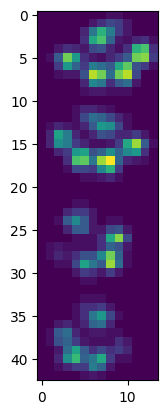

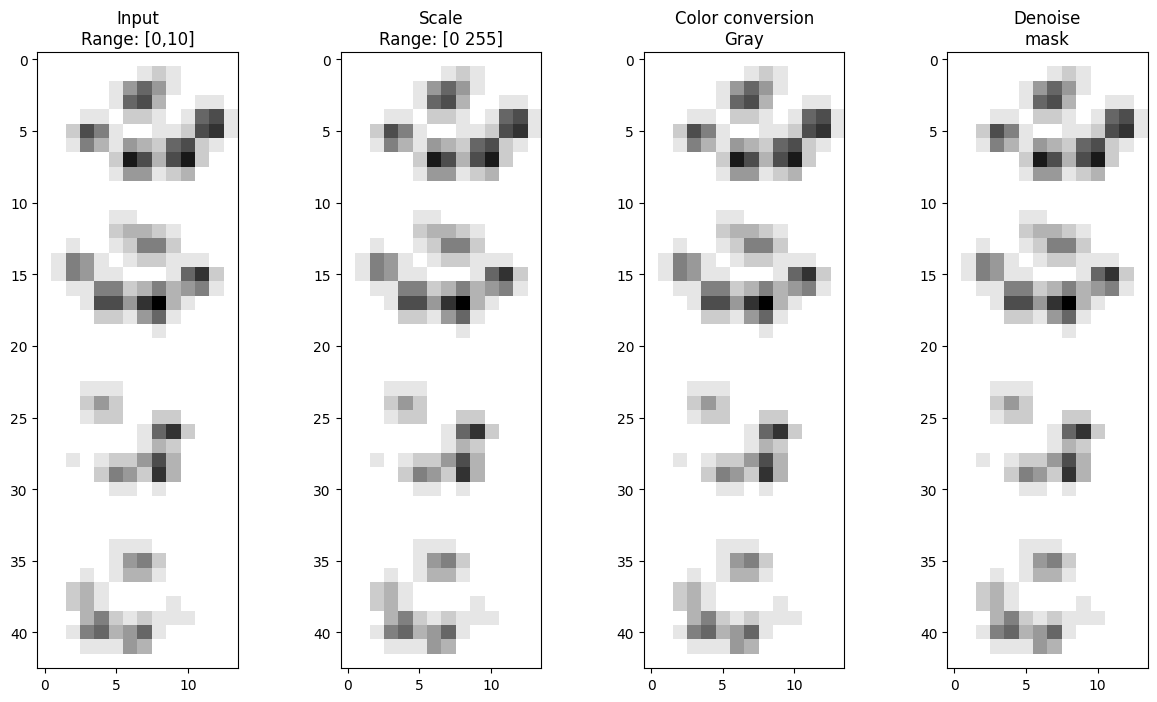

In [5]:
# Import library
from findpeaks import findpeaks
import matplotlib.pyplot as plt

# Initialize
fp = findpeaks(method='mask')
# Example 2d image
X = fp.import_example('2dpeaks')
# Plot RAW input image
plt.imshow(X)
# Fit using mask method
results = fp.fit(X)
# Plot the pre-processing steps
fp.plot_preprocessing()

INFO:findpeaks.findpeaks:Annotating peaks


dict_keys(['Xraw', 'Xproc', 'Xdetect', 'Xranked'])


20it [00:00, 1807.19it/s]
INFO:findpeaks.findpeaks:Annotating valleys
0it [00:00, ?it/s]


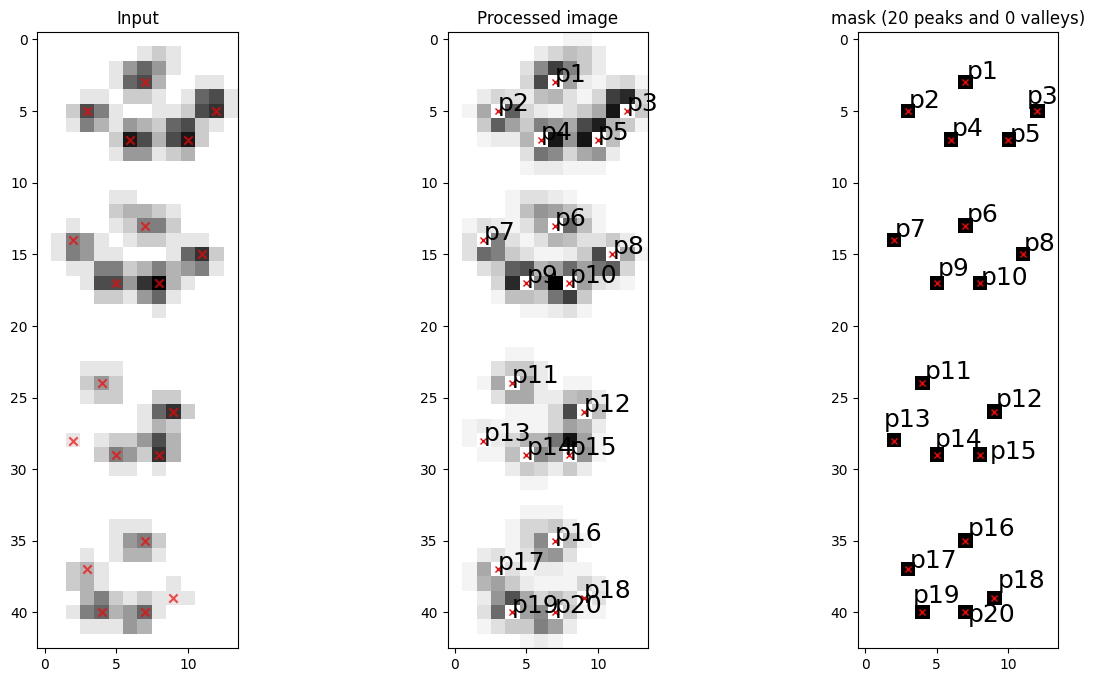

(<Axes: title={'center': 'Input'}>,
 <Axes: title={'center': 'Processed image'}>,
 <Axes: title={'center': 'mask (20 peaks and 0 valleys)'}>)

In [6]:
# The output contains multiple variables
print(results.keys())
# dict_keys(['Xraw', 'Xproc', 'Xdetect'])

# Plot detected peaks
fp.plot(figure_order='horizontal')

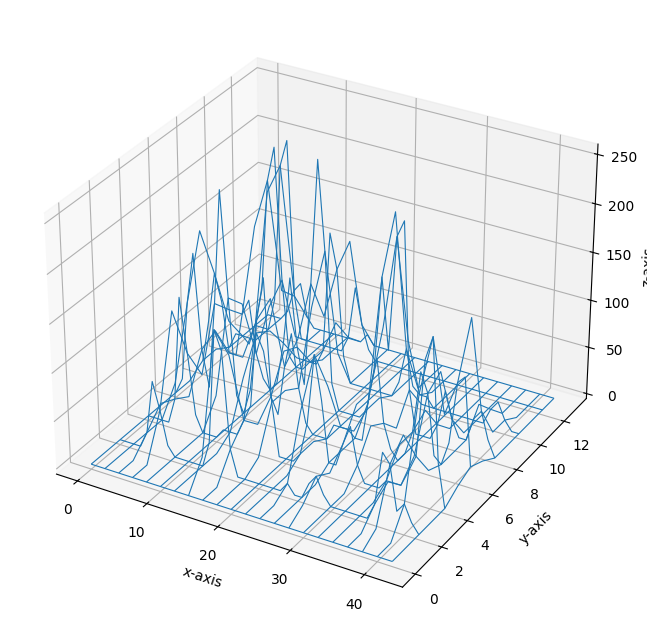

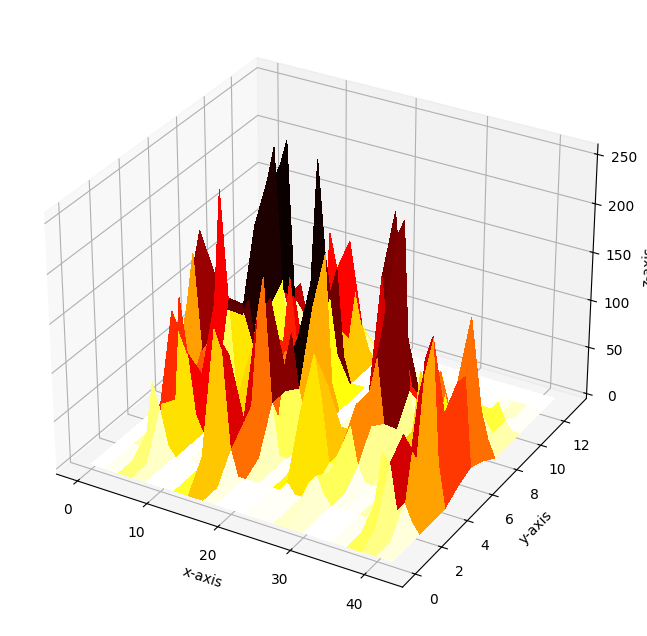

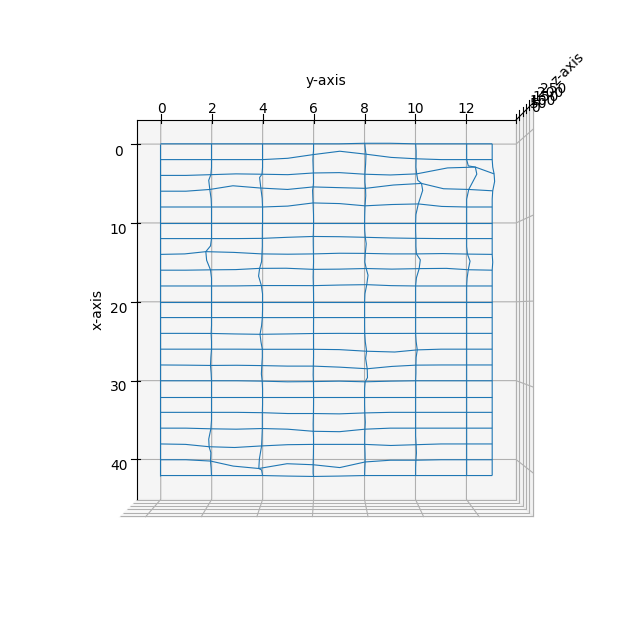

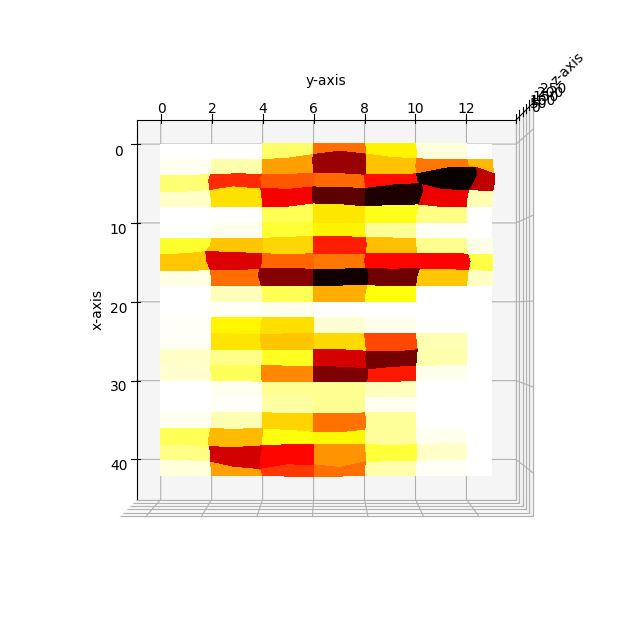

(<Axes3D: xlabel='x-axis', ylabel='y-axis', zlabel='z-axis'>,
 <Axes3D: xlabel='x-axis', ylabel='y-axis', zlabel='z-axis'>)

In [7]:
# Create mesh plot from 2D image.
fp.plot_mesh()

# Rotate to make a top view
fp.plot_mesh(view=(90,0))

# 3. Peak Detection With The Peakdetect Method

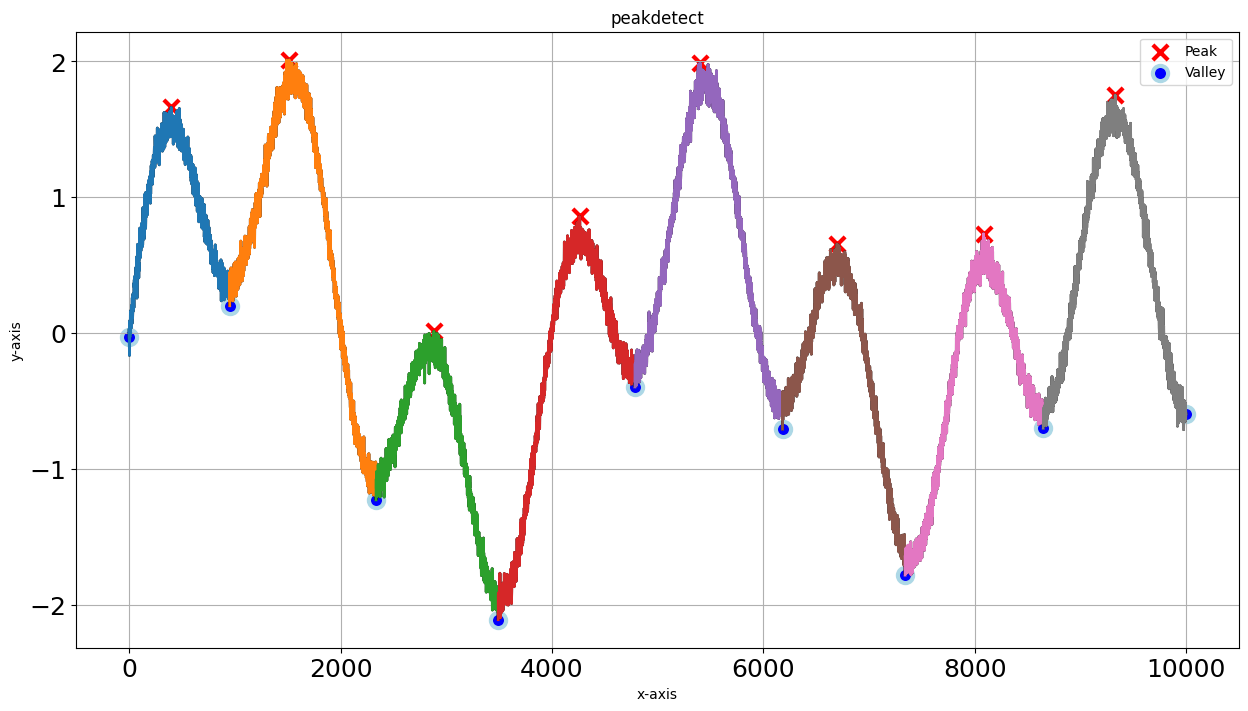

(None,
 <Axes: title={'center': 'peakdetect'}, xlabel='x-axis', ylabel='y-axis'>)

In [8]:
# Import libraries
import numpy as np
from findpeaks import findpeaks

# Create example data set
i = 10000
xs = np.linspace(0,3.7*np.pi,i)
X = (0.3*np.sin(xs) + np.sin(1.3 * xs) + 0.9 * np.sin(4.2 * xs) + 0.06 * np.random.randn(i))
# Initialize
fp = findpeaks(method='peakdetect', lookahead=200, interpolate=None)
# Fit peakdetect method
results = fp.fit(X)
# Plot
fp.plot()

# 4. Peak Detection With Caerus: Stock Market Analysis

INFO:caerus.caerus:Downloading example dataset..
INFO:caerus.caerus:Import dataset..
INFO:caerus.caerus:Start run with window: 50, minperc: 5, nlargest: 10 and threshold: 0.25
[caerus] Compute region scores..: 100%|██████████| 48/48 [00:00<00:00, 290.09it/s]
INFO:caerus.helper:Creating Plot..


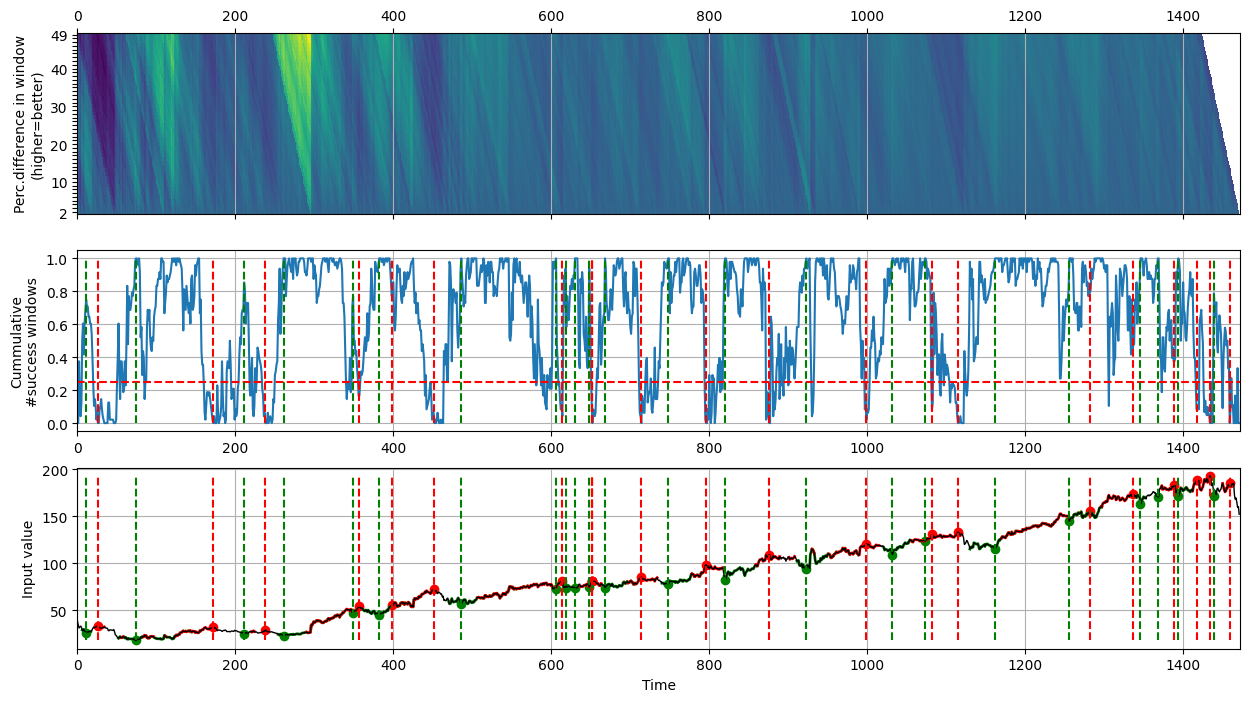

(<Figure size 1500x800 with 3 Axes>,
 (<Axes: ylabel='Perc.difference in window\n(higher=better)'>,
  <Axes: ylabel='Cummulative\n#success windows'>,
  <Axes: xlabel='Time', ylabel='Input value'>))

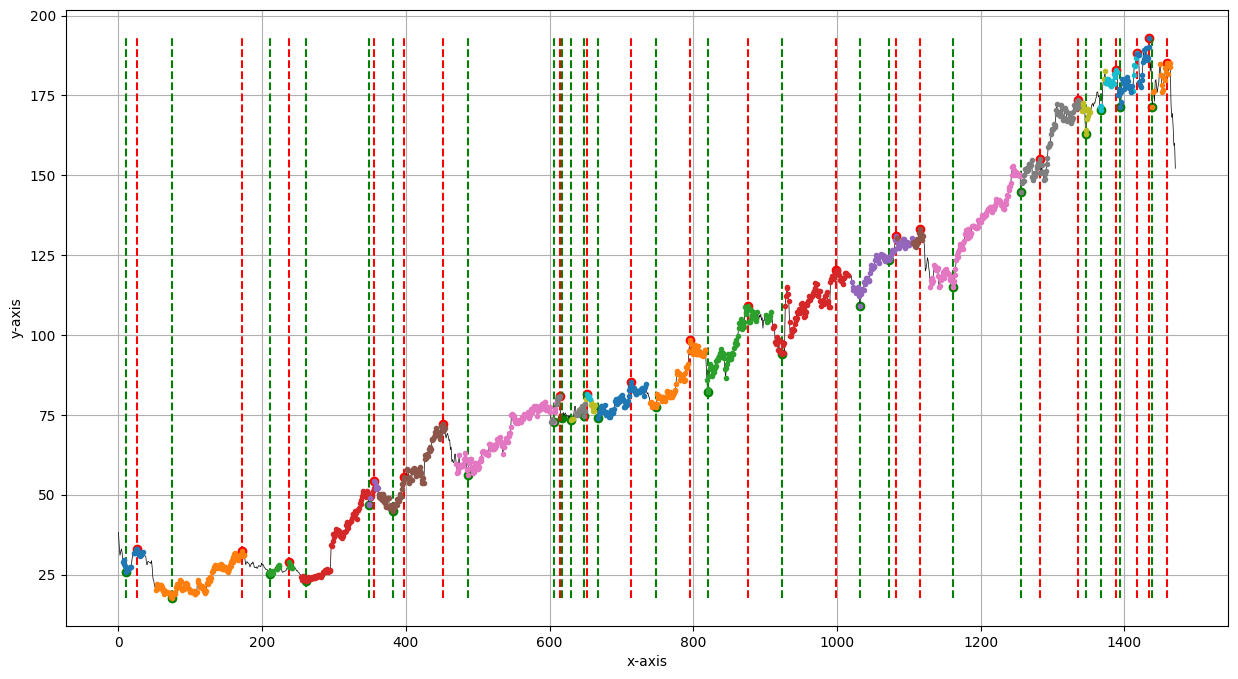

In [9]:
# Import library
from findpeaks import findpeaks

# Initialize findpeaks with cearus method.
# The default setting is that it only return peaks-vallyes with at least 5% difference.
fp = findpeaks(method='caerus', params={'minperc':5, 'window':50})
# Import example data
X = fp.import_example('facebook')
# Fit
results = fp.fit(X)
# Make the plot
fp.plot()

# Peak Detection in Noisy SAR images

INFO:findpeaks.findpeaks:Downloading from github source: [https://erdogant.github.io/datasets/2dpeaks_image.png]
INFO:findpeaks.findpeaks:Import [/usr/local/lib/python3.12/dist-packages/findpeaks/data/2dpeaks_image.png]
INFO:findpeaks.stats:Resizing image to (300, 300).
INFO:findpeaks.stats:Conversion to gray image.
INFO:findpeaks.stats:Detect peaks using topology method with limit at 2.0.
INFO:findpeaks.stats:Topology
90000it [00:01, 47661.04it/s]
INFO:findpeaks.stats:Detect peaks using topology method with limit at 2.0.
INFO:findpeaks.stats:Topology
89999it [00:01, 52033.80it/s]
INFO:findpeaks.findpeaks:Fin.
INFO:findpeaks.stats:Resizing image to (300, 300).


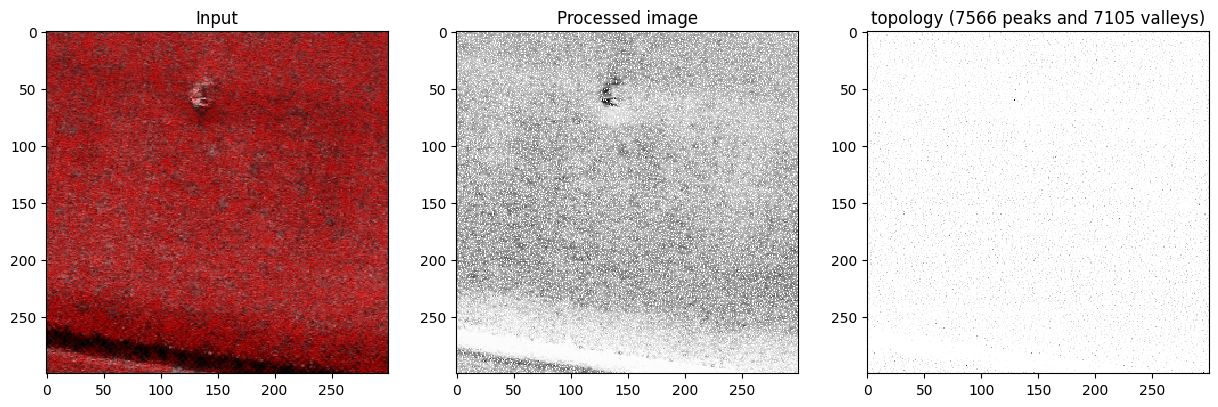

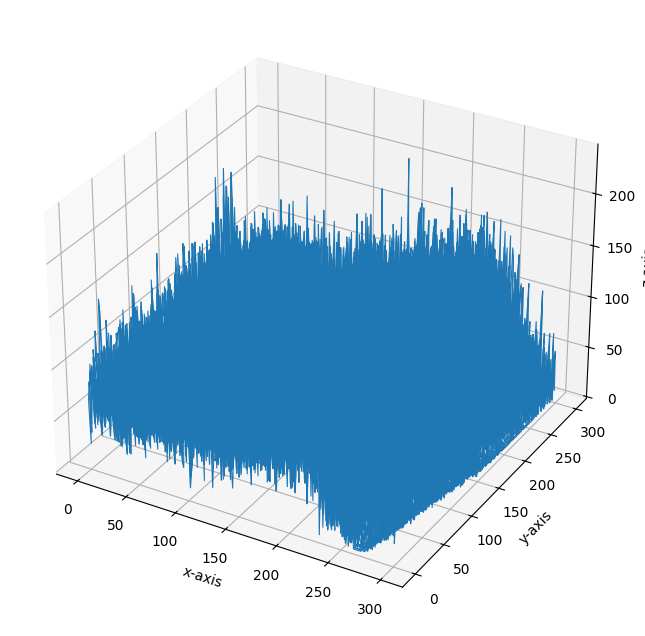

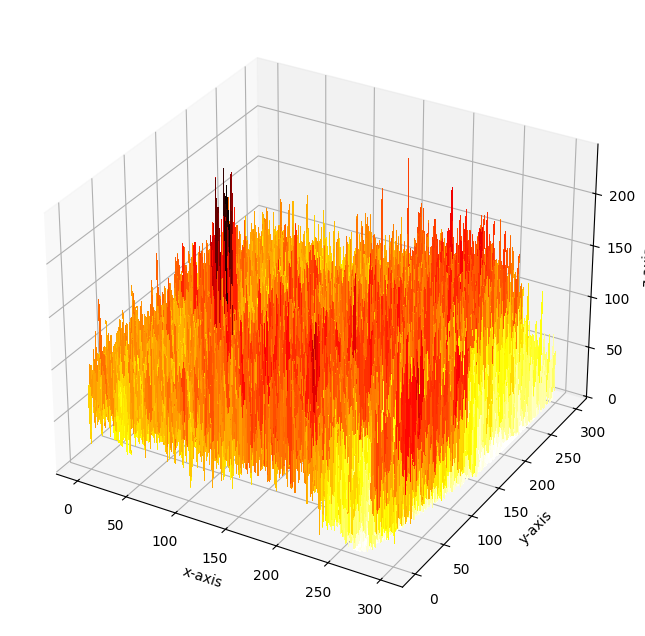

(<Axes3D: xlabel='x-axis', ylabel='y-axis', zlabel='z-axis'>,
 <Axes3D: xlabel='x-axis', ylabel='y-axis', zlabel='z-axis'>)

In [10]:
# Import library
from findpeaks import findpeaks
# Initializatie
fp = findpeaks(scale=None, denoise=None, togray=True, imsize=(300, 300))
# Import image example
img = fp.import_example('2dpeaks_image')
# Fit
fp.fit(img)
# Tens of thousands of peaks are detected at this point. Better to put text=False
fp.plot(figure_order='horizontal', text=False, alpha=0.1)
fp.plot_mesh()

INFO:findpeaks.findpeaks:Import [/usr/local/lib/python3.12/dist-packages/findpeaks/data/2dpeaks_image.png]
INFO:findpeaks.stats:Resizing image to (300, 300).
INFO:findpeaks.stats:Scaling image between [0-255] and to uint8
INFO:findpeaks.stats:Conversion to gray image.
INFO:findpeaks.stats:Denoising with [fastnl], window: [31].
INFO:findpeaks.stats:Detect peaks using topology method with limit at 0.0.
INFO:findpeaks.stats:Topology
90000it [00:02, 42338.73it/s]
INFO:findpeaks.stats:Detect peaks using topology method with limit at 0.0.
INFO:findpeaks.stats:Topology
90000it [00:01, 57491.69it/s]
INFO:findpeaks.findpeaks:Fin.
INFO:findpeaks.stats:Resizing image to (300, 300).
INFO:findpeaks.stats:Scaling image between [0-255] and to uint8
INFO:findpeaks.stats:Conversion to gray image.
INFO:findpeaks.stats:Denoising with [fastnl], window: [31].


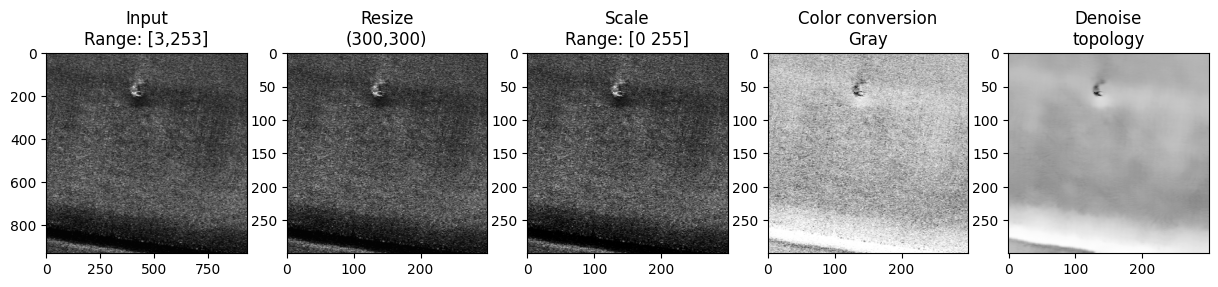

In [11]:
# Import library
from findpeaks import findpeaks
# Initializatie
fp = findpeaks(method='topology',
               togray=True,
               imsize=(300, 300),
               scale=True,
               denoise='fastnl',
               params={'window': 31})

# Import image example
img = fp.import_example('2dpeaks_image')
# Fit
fp.fit(img)
# Plot
fp.plot_preprocessing()

In [12]:
# Plot the top 5 peaks that are detected and examine the scores
fp.results['persistence'][0:5]

,x,y,birth_level,death_level,score,peak,valley
0,135,64,228.0,0.0,228.0,True,False
1,182,299,-227.0,-0.0,227.0,False,True
2,113,299,114.0,6.0,108.0,True,False
3,131,52,166.0,103.0,63.0,True,False
4,132,61,223.0,167.0,56.0,True,False


INFO:findpeaks.stats:Resizing image to (300, 300).
INFO:findpeaks.findpeaks:Annotating peaks
4it [00:00, 1227.84it/s]
INFO:findpeaks.findpeaks:Annotating valleys
1it [00:00, 1149.44it/s]


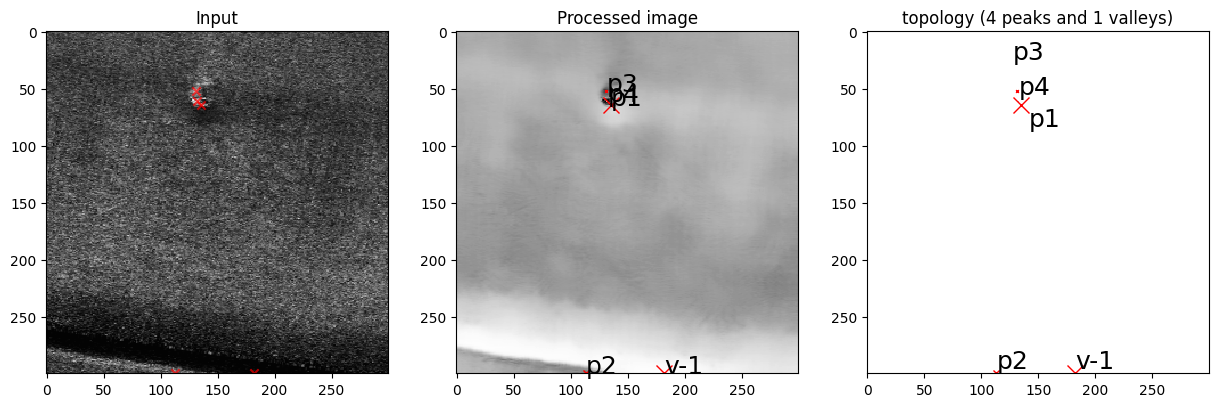

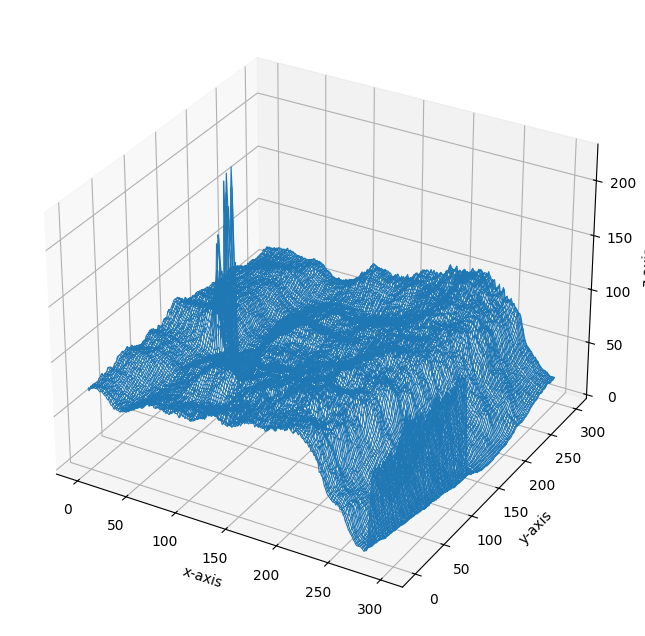

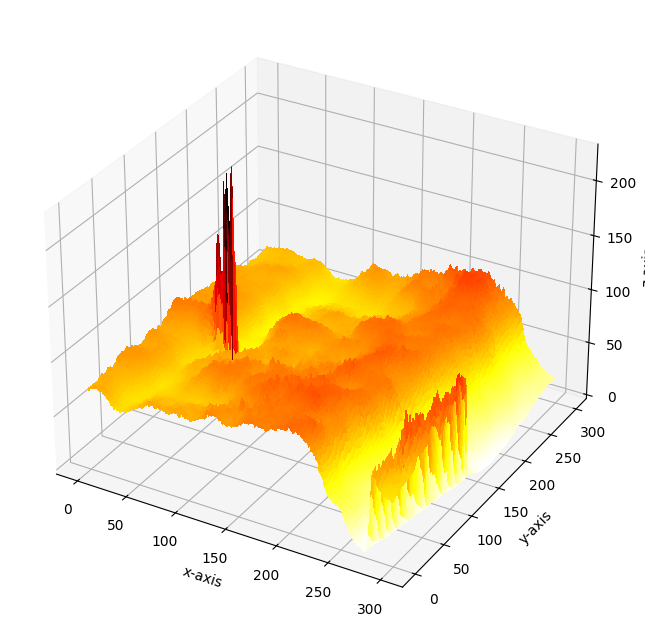

(<Axes3D: xlabel='x-axis', ylabel='y-axis', zlabel='z-axis'>,
 <Axes3D: xlabel='x-axis', ylabel='y-axis', zlabel='z-axis'>)

In [13]:
# Take the minimum score for the top peaks off the diagonal.
limit = fp.results['persistence'][0:5]['score'].min()
# Plot
fp.plot(limit=limit, figure_order='horizontal')
# Mesh plot
fp.plot_mesh()